# Calibration polynomial on six DR2 galaxies: baseline, poly3, poly3_total

- Fits from `scripts/calibration_arms_vast.py` on one Vast RTX 5060.
- Production sampler settings and production seed per target.
- `baseline`: production configuration (`spectrum_scaling` + `log_f_calib`).
- `poly3`: adds the marginalised order-3 Chebyshev polynomial.
- `poly3_total`: `poly3` anchored to the Laigle+16 total photometry.
- Two M5_172669 mocks with a 4 percent tilt on the spectrum only.


In [1]:
import os
import shutil
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial.chebyshev import chebvander
from scipy.special import softmax

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", "/Users/liuhao/Downloads/Astro project"))
RESULTS = Path(os.environ.get("CALIB_RESULTS_ROOT", PROJECT_ROOT / "results/calibration-polynomial-dr2"))
WIKI_FIGURES = Path(os.environ.get("CALIB_WIKI_FIGURES", PROJECT_ROOT / "wiki/analyses/calibration-polynomial-dr2"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from build_dr2_quiescent_summary import FEH_OFFSET, formation_times  # noqa: E402
from spectral_figures import mark_absorption_features, spectral_tight_layout  # noqa: E402

ARMS = ["baseline", "poly3", "poly3_total"]
MOCK_ARMS = ["mock_tilt4_baseline", "mock_tilt4_poly3"]
COLOURS = {"baseline": "0.35", "poly3": "tab:green", "poly3_total": "tab:blue",
           "mock_tilt4_baseline": "0.35", "mock_tilt4_poly3": "tab:green"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "t50": r"$t_{50}$ [Gyr]",
          "log_sfr": r"$\log_{10}\,\mathrm{SFR}_{0-30\,\mathrm{Myr}}\,[M_\odot\,\mathrm{yr}^{-1}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]",
          "Z": r"$[\mathrm{Fe}/\mathrm{H}]$", "afe": r"$[\alpha/\mathrm{Fe}]$"}


def _text(value):
    return value.decode() if isinstance(value, bytes) else str(value)


def load_fit(folder: Path) -> dict:
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as derived:
        out["attrs"] = dict(derived.attrs)
        names = [_text(v) for v in derived["summary/parameter"][:]]
        out["summary"] = pd.DataFrame(
            {"q16": derived["summary/q16"][:], "q50": derived["summary/q50"][:],
             "q84": derived["summary/q84"][:]}, index=names)
        out["diag"] = dict(derived["diagnostics"].attrs)
        out["spectrum"] = {k: derived["spectrum"][k][:] for k in derived["spectrum"]}
        out["photometry"] = {k: derived["photometry"][k][:] for k in derived["photometry"]}
        out["sfh"] = {k: derived["sfh"][k][:] for k in derived["sfh"]}
        out["calibration"] = None
        if "calibration" in derived:
            out["calibration"] = {k: derived["calibration"][k][:] for k in derived["calibration"]}
            out["calibration"]["attrs"] = dict(derived["calibration"].attrs)
        out["truth"] = ({k: np.asarray(derived["mock_truth"][k][:]) for k in derived["mock_truth"]}
                        if "mock_truth" in derived else None)
    with h5py.File(folder / "ceridwen_result.h5", "r") as result:
        out["model_attrs"] = dict(result["model"].attrs)
        out["n_calls"] = int(result["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(result["samples"].attrs["wall_time_s"])
    return out


def find_fits() -> dict:
    fits = {}
    for arm_dir in sorted(p for p in RESULTS.iterdir() if p.is_dir()):
        for folder in sorted(arm_dir.iterdir()):
            if (folder / "ceridwen_derived_outputs.h5").exists():
                target = folder.name.split("-", 1)[1]
                fits[(arm_dir.name, target)] = load_fit(folder)
    return fits


fits = find_fits()
galaxies = sorted({t for a, t in fits if a in ARMS},
                  key=lambda t: fits[("baseline", t)]["attrs"]["catalogue_sn"] if ("baseline", t) in fits else 0)
print(len(fits), "fits;", "galaxies:", galaxies)
print("mock arms:", [a for a, t in fits if a in MOCK_ARMS])


20 fits; galaxies: ['M12_98104', 'M5_173928', 'M4_108989', 'M12_185653', 'M1_206545', 'M5_172669']
mock arms: ['mock_tilt4_baseline', 'mock_tilt4_poly3']


## Summary table

- One row per galaxy and arm.
- Raw χ² uses the observational σ, stored χ² the fitted σ_eff.
- $t_{50}$ from `formation_times`; SFR from the youngest SFH bin and the median mass.


In [2]:
def half_width(row):
    return 0.5 * (row["q84"] - row["q16"])


def derived_row(arm, target, fit):
    spec = fit["spectrum"]
    mask = spec["mask"].astype(bool)
    raw_chi2 = float(np.sum(((spec["observed"] - spec["posterior_q50"]) / spec["uncertainty"])[mask] ** 2))
    summary = fit["summary"]
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    logmass_q50 = summary.loc["logmass", "q50"]
    sfr = fit["sfh"]["normalized_sfr_draws"][:, 0] * 10 ** logmass_q50
    row = dict(arm=arm, target=target, z=fit["attrs"]["redshift"], sn=fit["attrs"]["catalogue_sn"],
               photometry=fit["attrs"].get("photometry_source", "cosmos_ap3"),
               order=int(fit["attrs"].get("calibration_order", 0)),
               n_pix=int(fit["diag"]["spectrum_ndof"]),
               spec_chi2_stored=float(fit["diag"]["spectrum_chi2"]), spec_chi2_raw=raw_chi2,
               phot_chi2=float(fit["diag"]["photometry_chi2"]),
               lnZ=float(fit["diag"]["log_evidence"]), lnZ_err=float(fit["diag"]["log_evidence_err"]),
               ess=float(fit["diag"]["posterior_weight_ess"]), passed=bool(fit["diag"]["passed"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]"),
                      ("scaling", "spectrum_scaling")]:
        row[f"{name}_q50"] = summary.loc[key, "q50"]
        row[f"{name}_hw"] = half_width(summary.loc[key])
    row["Z_q50"] += FEH_OFFSET  # grid Z -> [Fe/H]
    for name, draws in [("t50", t50), ("log_sfr", np.log10(np.clip(sfr, 1e-30, None)))]:
        q16, q50, q84 = np.percentile(draws, [16, 50, 84])
        row[f"{name}_q50"], row[f"{name}_hw"] = q50, 0.5 * (q84 - q16)
    if fit["calibration"] is not None:
        p = fit["calibration"]["polynomial_q50"][mask]
        row["P_min"], row["P_max"], row["P_tilt"] = p.min(), p.max(), p[-1] / p[0] - 1.0
        for i in range(fit["calibration"]["coefficient_draws"].shape[1]):
            q16, q50, q84 = np.percentile(fit["calibration"]["coefficient_draws"][:, i], [16, 50, 84])
            row[f"a{i + 1}_q50"], row[f"a{i + 1}_hw"] = q50, 0.5 * (q84 - q16)
    return row


table = pd.DataFrame([derived_row(a, t, f) for (a, t), f in fits.items()])
table = table.set_index(["target", "arm"]).sort_index()
table.to_csv(RESULTS / "arms.csv")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
show = ["z", "sn", "photometry", "order", "n_pix", "spec_chi2_raw", "spec_chi2_stored", "phot_chi2",
        "f_calib_q50", "scaling_q50", "logmass_q50", "logmass_hw", "t50_q50", "t50_hw", "log_sfr_q50",
        "tau_dust_q50", "age_q50", "age_hw", "P_min", "P_max", "P_tilt", "lnZ", "calls", "wall_s"]
display(table[[c for c in show if c in table]].round(3))


z     sn    photometry  order  n_pix  spec_chi2_raw  spec_chi2_stored  phot_chi2  f_calib_q50  scaling_q50  logmass_q50  logmass_hw  t50_q50  t50_hw  log_sfr_q50  tau_dust_q50  age_q50  age_hw  P_min  P_max  \
target     arm                                                                                                                                                                                                                                       
M12_185653 baseline             0.678   21.5    cosmos_ap3      0   3577      10152.758          4016.683     36.607        6.429        1.118       10.897       0.009    3.013   0.047       -3.522         0.106    3.021   0.053    NaN    NaN   
           poly3                0.678   21.5    cosmos_ap3      3   3577       9844.411          3961.088     39.236        6.338        1.143       10.996       0.054    4.514   0.819       -3.129         0.191    4.501   0.655  0.968  1.041   
           poly3_total          0.678   21.5  cosmos_total      3   3577       9844.152          3968.989     11.112        6.317        0.980       11.100       0.035    5.056   0.454       -1.361         0.172    5.017   0.370  0.956  1.041   
M12_98104  baseline             0.981    6.6    cosmos_ap3      0   3804       8664.348          5913.643     49.474        9.980        1.369       11.090       0.010    2.995   0.052        0.420         0.481    2.995   0.045    NaN    NaN   
           poly3                0.981    6.6    cosmos_ap3      3   3804       8652.445          5912.840     44.789        9.976        1.284       11.075       0.045    3.042   0.576       -0.150         0.440    3.041   0.484  0.977  1.040   
           poly3_total          0.981    6.6  cosmos_total      3   3804       8655.031          5917.863     10.090        9.978        0.970       11.248       0.026    4.442   0.420       -0.795         0.363    4.403   0.267  0.943  1.082   
M1_206545  baseline             0.728   31.4    cosmos_ap3      0   3422      12772.106          4406.263    133.237        5.713        1.380       11.244       0.009    2.935   0.050       -0.551         0.189    2.964   0.058    NaN    NaN   
           poly3                0.728   31.4    cosmos_ap3      3   3422       8580.668          4387.589    101.905        3.806        1.775       11.540       0.010    5.071   0.045        1.262         0.585    5.064   0.025  0.870  1.146   
           poly3_total          0.728   31.4  cosmos_total      3   3422       8661.358          4302.297     64.639        3.948        1.162       11.638       0.009    5.071   0.025        1.273         0.457    5.065   0.015  0.831  1.133   
M4_108989  baseline             0.828   21.3    cosmos_ap3      0   3735       9107.308          4491.261    139.141        4.606        1.484       11.638       0.012    4.653   0.085        0.735         0.327    4.619   0.082    NaN    NaN   
           poly3                0.828   21.3    cosmos_ap3      3   3735       8493.455          4429.639    152.640        4.130        1.778       11.597       0.030    3.092   0.441        1.311         0.562    3.092   0.423  0.866  1.158   
           poly3_total          0.828   21.3  cosmos_total      3   3735       8640.260          4263.885     12.849        4.387        0.823       11.811       0.016    4.635   0.112        0.599         0.253    4.610   0.116  0.947  1.047   
M5_172669  baseline             0.604  105.0    cosmos_ap3      0   3602      31246.059          3823.820    170.900        2.894        1.238       11.109       0.007    1.656   0.011       -3.757         0.012    1.663   0.020    NaN    NaN   
           mock_tilt4_baseline  0.604  105.0    cosmos_ap3      0   3602       3625.097          1833.686     22.521        1.001        1.289       11.167       0.011    1.708   0.042        0.090         0.151    1.769   0.110    NaN    NaN   
           mock_tilt4_poly3     0.604  105.0    cosmos_ap3      3   3602       3589.952          181

## Before and after per galaxy

- Δχ² = polynomial arm minus baseline, per galaxy.
- `repeat` = production fit of the same galaxy and seed (2026-08-31) minus this baseline: the run-to-run scatter of the stored χ².
- `dchi2_basew`: both fits scored with the baseline σ_eff (its $f_{\rm calib}$), so the weights are equal.


In [3]:
production = pd.read_csv(PROJECT_ROOT / "archive/results/dr2-quiescent-no-polynomial/dr2-quiescent-summary.csv").set_index("spect_id")


def chi2_at_f(fit, f_pct):
    spec = fit["spectrum"]
    mask = spec["mask"].astype(bool)
    sigma = np.hypot(spec["uncertainty"], (f_pct / 100.0) * np.abs(spec["posterior_q50"]))
    return float(np.sum(((spec["observed"] - spec["posterior_q50"]) / sigma)[mask] ** 2))


rows = []
for target in galaxies:
    base = table.loc[(target, "baseline")]
    base_chi2_fixed = chi2_at_f(fits[("baseline", target)], base["f_calib_q50"])
    repeat = production.loc[target, "spectrum_chi2"] - base["spec_chi2_stored"] if target in production.index else np.nan
    for arm in ["poly3", "poly3_total"]:
        if (target, arm) not in table.index:
            continue
        cur = table.loc[(target, arm)]
        rows.append(dict(
            target=target, arm=arm,
            dchi2_raw=cur["spec_chi2_raw"] - base["spec_chi2_raw"],
            dchi2_stored=cur["spec_chi2_stored"] - base["spec_chi2_stored"],
            dchi2_basew=chi2_at_f(fits[(arm, target)], base["f_calib_q50"]) - base_chi2_fixed,
            repeat_dchi2_stored=repeat,
            dchi2_phot=cur["phot_chi2"] - base["phot_chi2"],
            dlnZ=cur["lnZ"] - base["lnZ"],
            df_calib=cur["f_calib_q50"] - base["f_calib_q50"],
            dlogmass=cur["logmass_q50"] - base["logmass_q50"],
            dt50=cur["t50_q50"] - base["t50_q50"],
            dlog_sfr=cur["log_sfr_q50"] - base["log_sfr_q50"],
            dtau=cur["tau_dust_q50"] - base["tau_dust_q50"],
            dage=cur["age_q50"] - base["age_q50"],
        ))
before_after = pd.DataFrame(rows).set_index(["target", "arm"]).sort_index()
before_after.to_csv(RESULTS / "before-after.csv")
display(before_after.round(3))

dchi2_raw  dchi2_stored  dchi2_basew  repeat_dchi2_stored  dchi2_phot     dlnZ  df_calib  dlogmass   dt50  dlog_sfr   dtau   dage
target     arm                                                                                                                                           
M12_185653 poly3         -308.347       -55.595     -133.729                4.374       2.629   53.216    -0.091     0.099  1.501     0.393  0.084  1.480
           poly3_total   -308.606       -47.694     -136.498                4.374     -25.495   67.673    -0.112     0.204  2.043     2.161  0.065  1.996
M12_98104  poly3          -11.903        -0.803       -1.993               -1.024      -4.685    0.132    -0.004    -0.016  0.047    -0.570 -0.041  0.046
           poly3_total     -9.317         4.221        3.749               -1.024     -39.384   18.062    -0.002     0.158  1.447    -1.214 -0.118  1.408
M1_206545  poly3        -4191.439       -18.675    -1316.926               -5.257     -31.332  812.630    -1.907     0.296  2.136     1.813  0.396  2.100
           poly3_total  -4110.748      -103.966    -1302.224               -5.257     -68.599  834.668    -1.765     0.394  2.136     1.824  0.268  2.101
M4_108989  poly3         -613.853       -61.622     -440.092              -23.806      13.499  202.316    -0.476    -0.042 -1.561     0.576  0.235 -1.527
           poly3_total   -467.048      -227.376     -392.592              -23.806    -126.293  250.016    -0.219     0.173 -0.017    -0.136 -0.074 -0.009
M5_172669  poly3        -2265.370       337.263     -193.228                2.058     -40.141  288.536    -0.234     0.167  0.097     5.518  0.642  0.221
           poly3_total  -2233.559       331.759     -191.222                2.058     -70.799  281.741    -0.232     0.220  0.112     5.520  0.565  0.182
M5_173928  poly3         -617.861       100.216      -27.077                0.637     -54.681    7.595    -0.242     0.158  2.581    -1.913 -0.077  2.514
           poly3_total   -568.561        81.652       -4.763                0.637     -95.146    3.516    -0.148     0.192  1.596    -1.849 -0.178  1.556

## Spectral χ² per galaxy, before and after

- Top: pull = (observed − q50) / σ_eff, fitted pixels only.
- Bottom: cumulative stored χ² along the spectrum.
- Grey band: masked pixels.


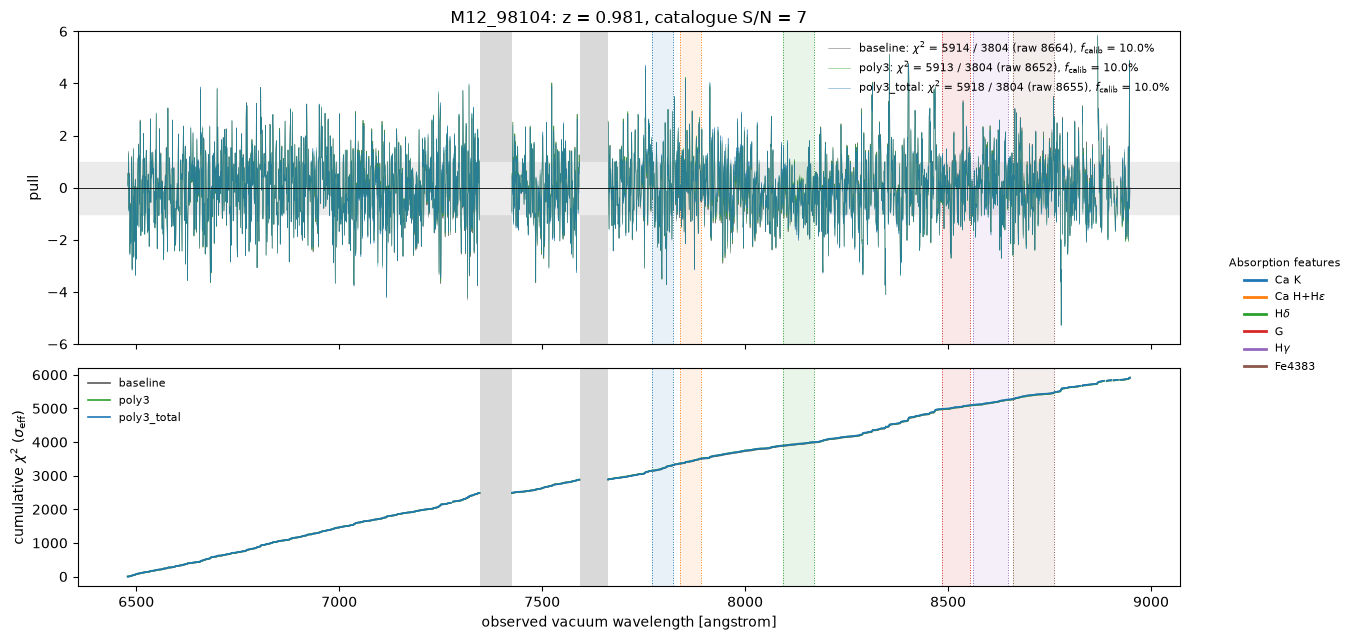

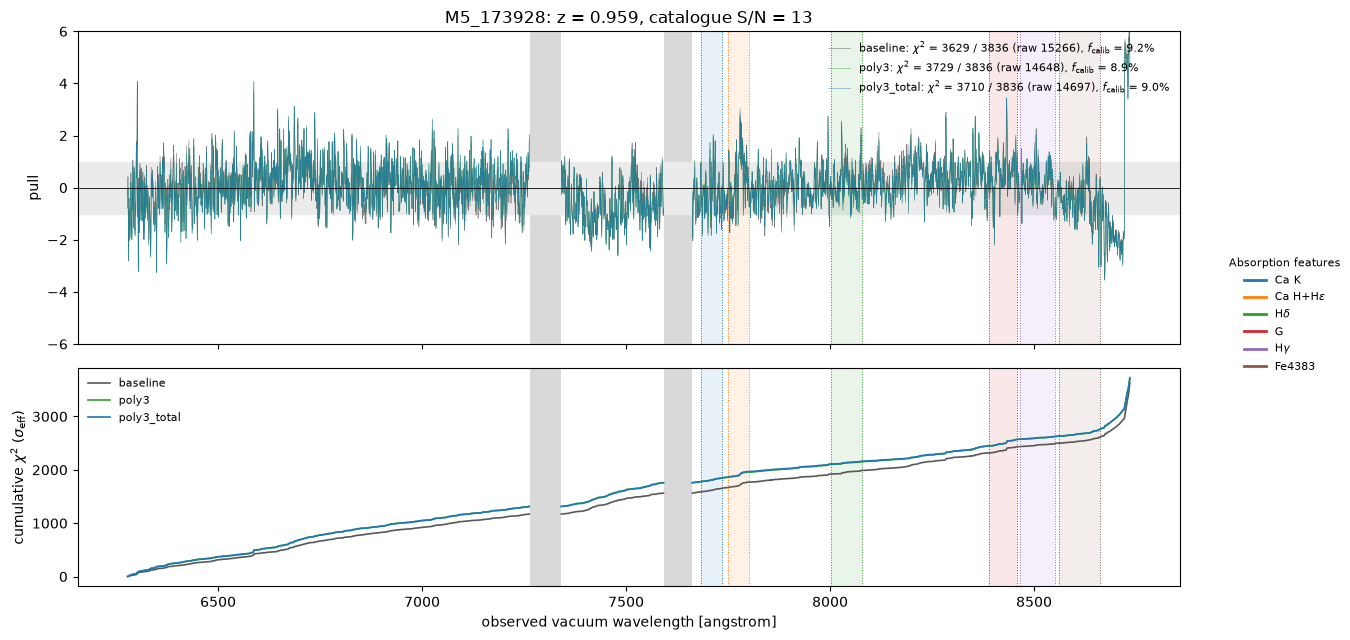

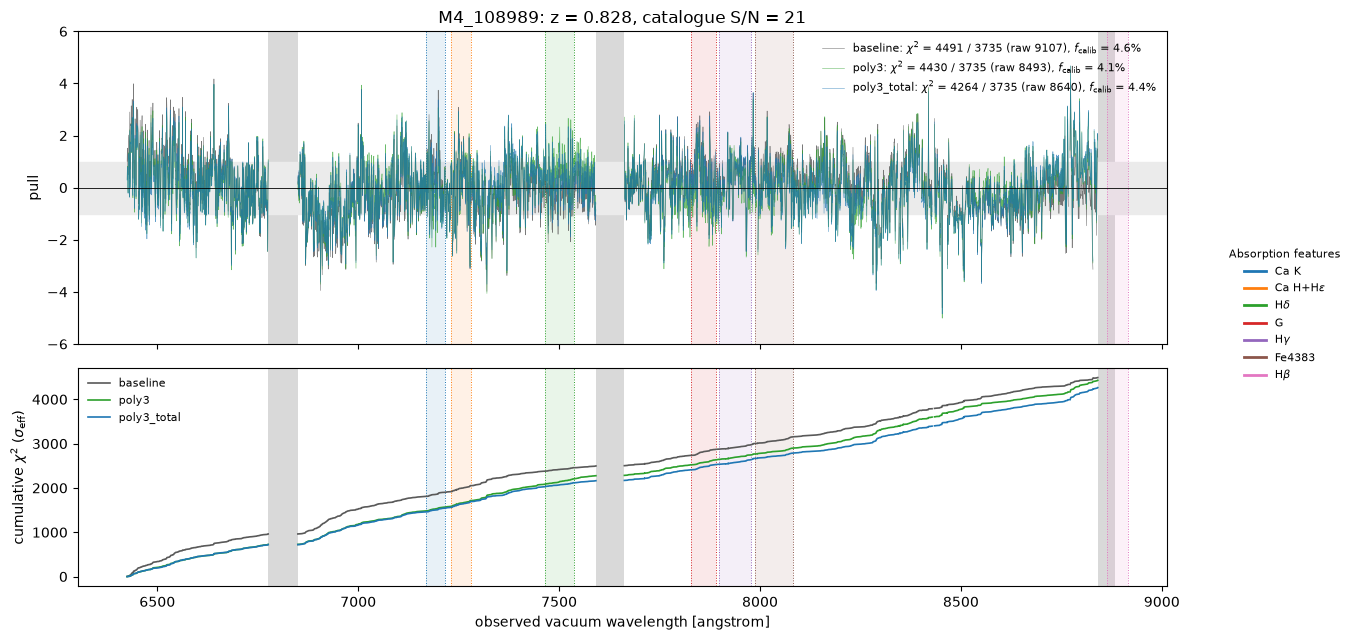

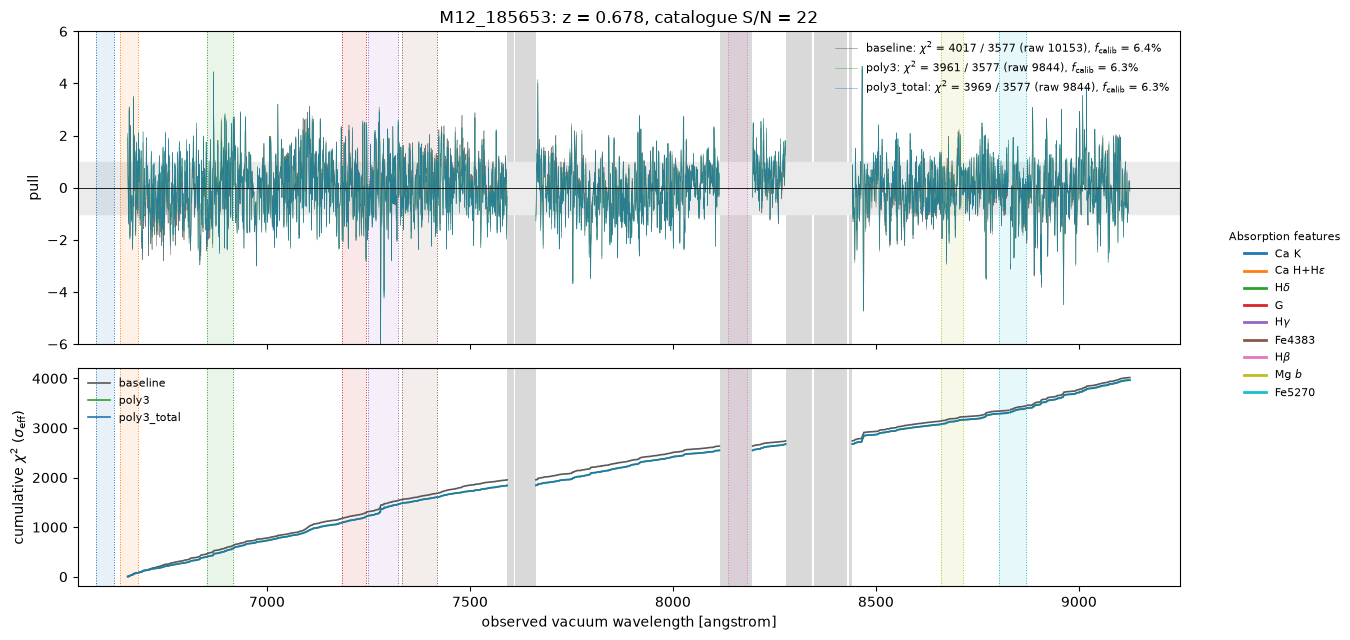

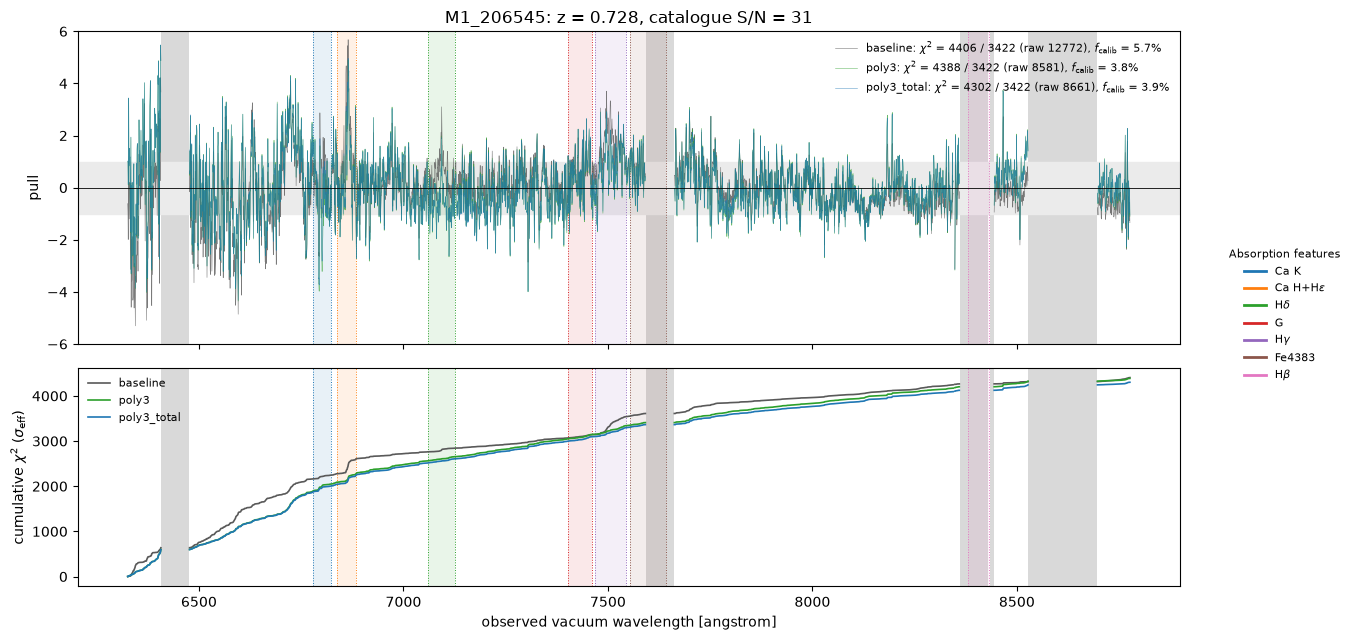

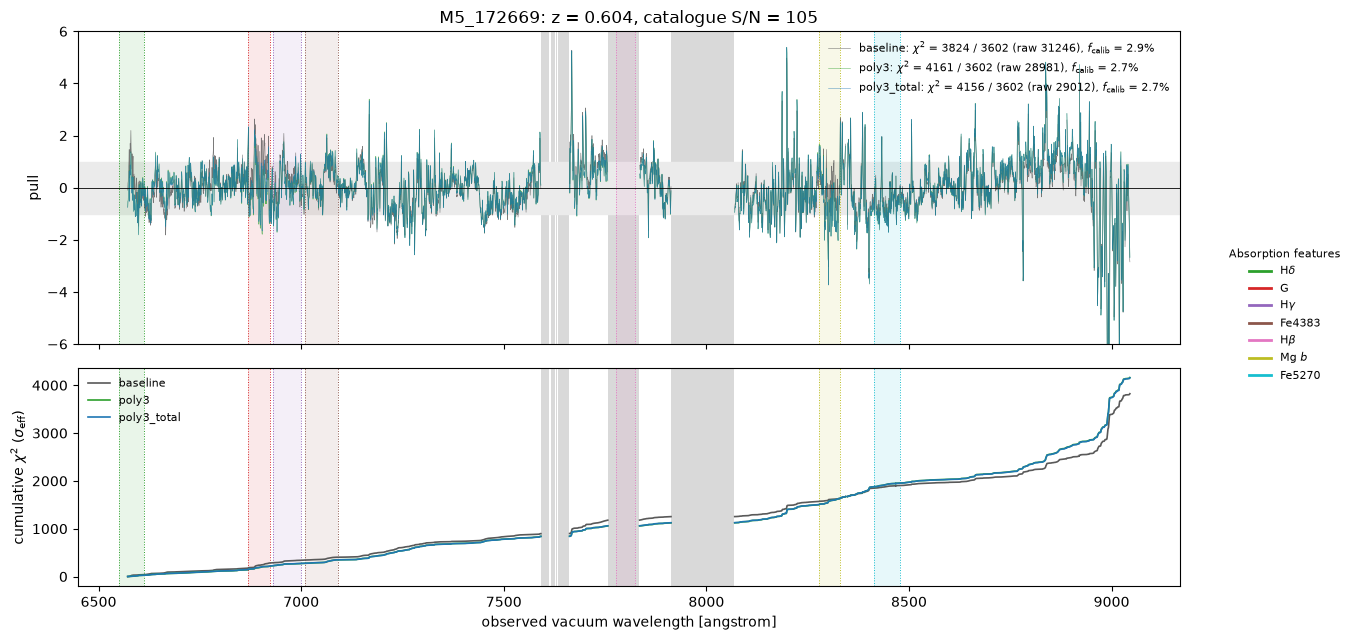

In [4]:
def spectral_figure(target):
    arms_here = [a for a in ARMS if (a, target) in fits]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1.4]})
    ref = fits[(arms_here[0], target)]["spectrum"]
    wave = ref["wavelength"]
    valid = ref["uncertainty"] < 1.0                      # unmasked-or-excluded native pixels
    excluded = valid & ~ref["mask"].astype(bool)
    for ax in axes:
        for lo, hi in _runs(wave, excluded):
            ax.axvspan(lo, hi, color="0.85", lw=0, zorder=0)
    for arm in arms_here:
        spec = fits[(arm, target)]["spectrum"]
        mask = spec["mask"].astype(bool)
        pull = np.where(mask, spec["pull"], np.nan)
        cumulative = np.where(mask, np.cumsum(np.where(mask, spec["pull"] ** 2, 0.0)), np.nan)
        row = table.loc[(target, arm)]
        axes[0].plot(wave, pull, lw=0.4, color=COLOURS[arm], alpha=0.8 if arm == "baseline" else 0.7,
                     label=f"{arm}: $\\chi^2$ = {row['spec_chi2_stored']:.0f} / {row['n_pix']} "
                           f"(raw {row['spec_chi2_raw']:.0f}), $f_{{\\rm calib}}$ = {row['f_calib_q50']:.1f}%")
        axes[1].plot(wave, cumulative, lw=1.2, color=COLOURS[arm], label=arm)
    axes[0].axhspan(-1, 1, color="0.92", zorder=0)
    axes[0].axhline(0, color="k", lw=0.6)
    axes[0].set_ylim(-6, 6)
    axes[0].set_ylabel("pull")
    axes[0].set_title(f"{target}: z = {fits[(arms_here[0], target)]['attrs']['redshift']:.3f}, "
                      f"catalogue S/N = {fits[(arms_here[0], target)]['attrs']['catalogue_sn']:.0f}")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1].set_ylabel(r"cumulative $\chi^2$ ($\sigma_{\rm eff}$)")
    zred = fits[(arms_here[0], target)]["attrs"]["redshift"]
    mark_absorption_features(axes[0], zred, show_labels=False)
    mark_absorption_features(axes[1], zred,
                             xlabel="observed vacuum wavelength [angstrom]")
    axes[1].legend(frameon=False, fontsize=8, loc="upper left")
    spectral_tight_layout(fig)
    fig.savefig(RESULTS / f"chi2-{target}.png", dpi=130)
    plt.show()


def _runs(wave, flag):
    edges = np.flatnonzero(np.diff(np.concatenate([[0], flag.astype(int), [0]])))
    return [(wave[max(s, 0)], wave[min(e, wave.size) - 1]) for s, e in zip(edges[::2], edges[1::2])]


for target in galaxies:
    spectral_figure(target)


## Size of the Occam term over the posterior

- −½ ln|N| with N = DᵀD + Σ_p⁻¹, evaluated at the uncalibrated median model.
- Varied over the 16-84 ranges of $f_{\rm calib}$ and the mass.
- Coefficient posterior half widths from the stored draws.


In [5]:
rows = []
for (arm, target), fit in sorted(fits.items()):
    cal = fit["calibration"]
    if cal is None:
        continue
    spec = fit["spectrum"]
    mask = spec["mask"].astype(bool)
    mu = spec["posterior_q50"] / cal["polynomial_q50"]            # uncalibrated median model
    basis = chebvander(cal["x"], int(cal["attrs"]["order"]))[:, 1:]
    precision = np.eye(basis.shape[1]) / float(cal["attrs"]["prior_sigma"]) ** 2
    f_lo, f_hi = fit["summary"].loc["calibration floor [%]", ["q16", "q84"]] / 100.0
    m_lo, m_hi = 10 ** (fit["summary"].loc["logmass", ["q16", "q84"]] - fit["summary"].loc["logmass", "q50"])
    values = []
    for f in (f_lo, f_hi):
        for scale in (m_lo, m_hi):
            model = scale * mu
            sigma_eff = np.hypot(spec["uncertainty"], f * np.abs(model))
            design = (basis * (model / sigma_eff)[:, None])[mask]
            values.append(-0.5 * np.linalg.slogdet(design.T @ design + precision)[1])
    widths = {f"a{i + 1}_hw": table.loc[(target, arm), f"a{i + 1}_hw"] for i in range(basis.shape[1])}
    rows.append(dict(arm=arm, target=target, occam_range_nats=max(values) - min(values), **widths))
occam = pd.DataFrame(rows).set_index(["target", "arm"]).sort_index()
display(occam.round(4))


occam_range_nats   a1_hw   a2_hw   a3_hw
target     arm                                                       
M12_185653 poly3                       0.3437  0.0087  0.0031  0.0027
           poly3_total                 0.2576  0.0090  0.0029  0.0029
M12_98104  poly3                       0.3649  0.0133  0.0064  0.0047
           poly3_total                 0.2268  0.0136  0.0060  0.0052
M1_206545  poly3                       0.1593  0.0063  0.0021  0.0021
           poly3_total                 0.1448  0.0074  0.0027  0.0019
M4_108989  poly3                       0.2633  0.0105  0.0028  0.0027
           poly3_total                 0.1804  0.0089  0.0031  0.0022
M5_172669  mock_tilt4_poly3            0.0853  0.0060  0.0006  0.0004
           poly3                       0.0966  0.0044  0.0013  0.0009
           poly3_total                 0.0897  0.0045  0.0013  0.0011
M5_173928  poly3                       0.2204  0.0088  0.0035  0.0033
           poly3_total                 0.1212  0.0078  0.0035  0.0033

## The calibration vector

- $P(\lambda)$: median and 16-84 band; dotted over masked pixels.
- Right: $s_{\mathrm{spectrum}}\,P(\lambda)$, the full model-to-data scale.


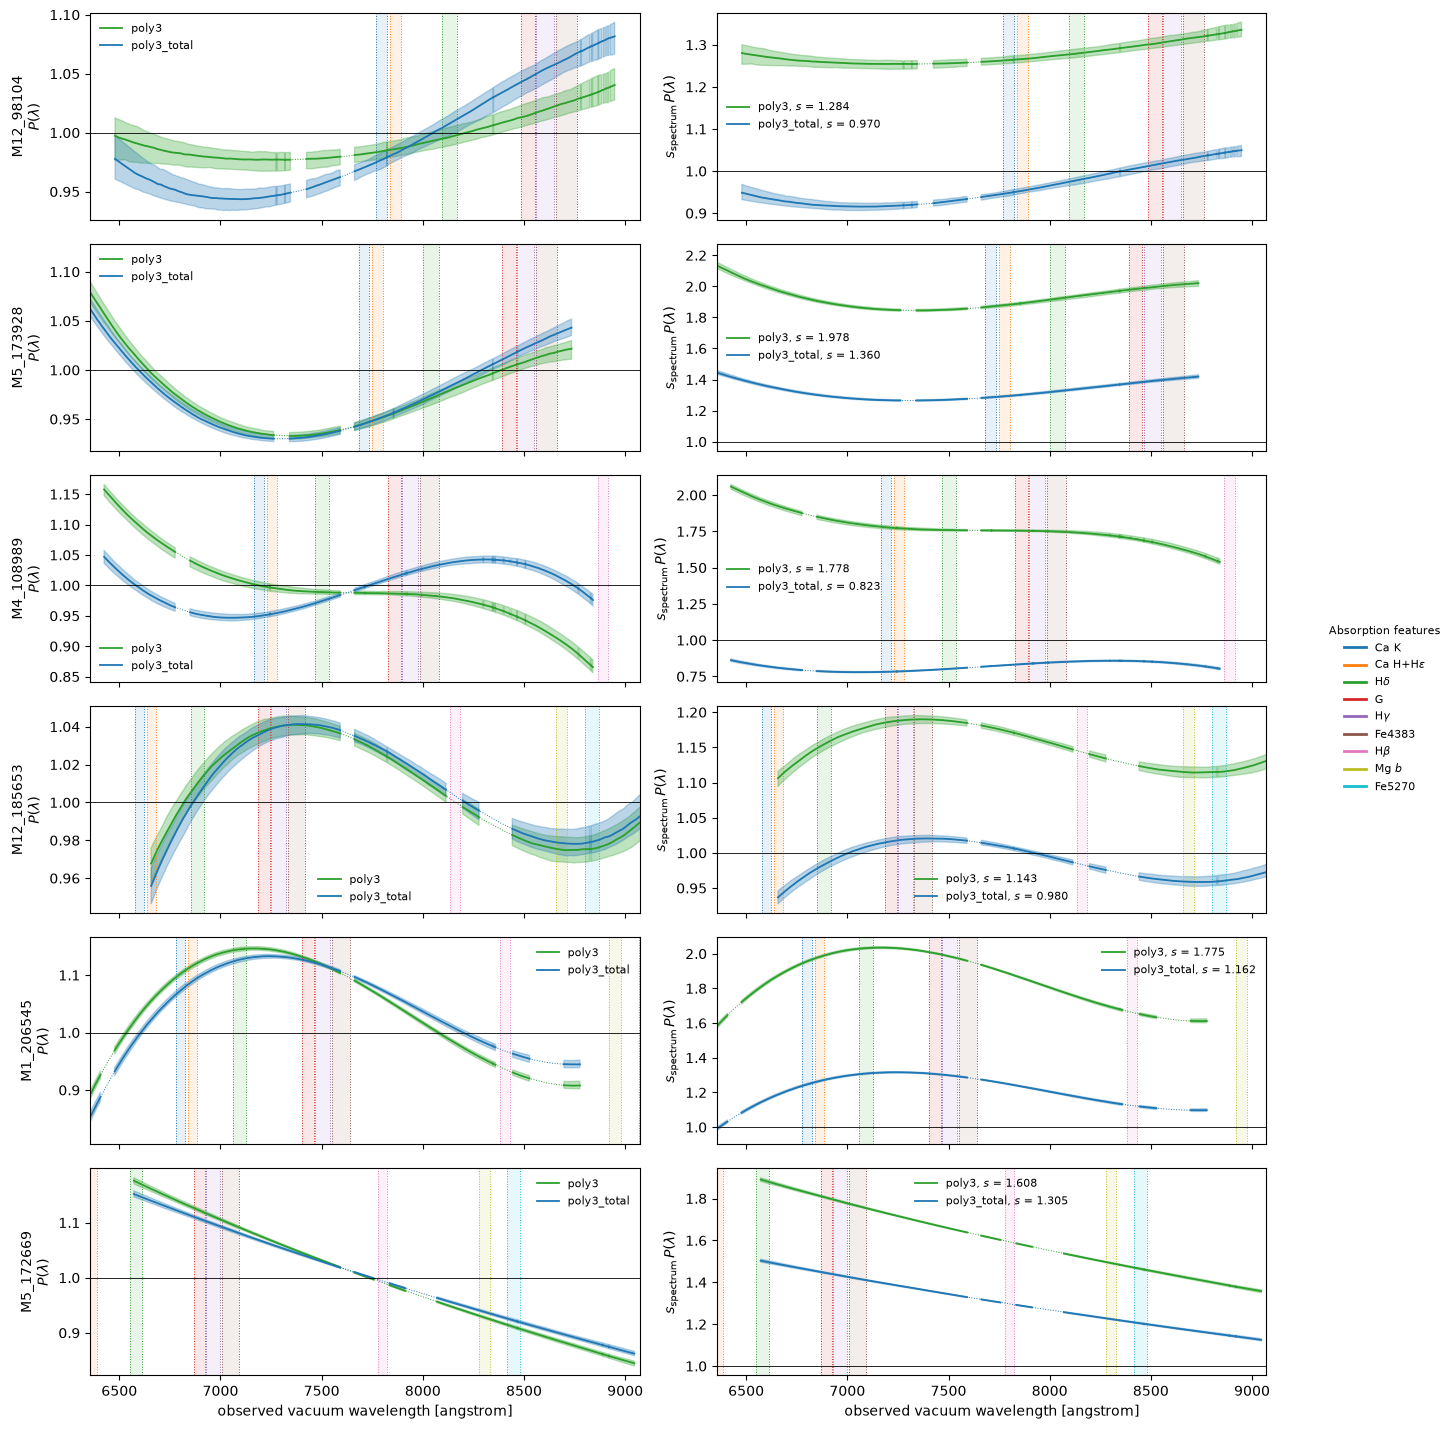

In [6]:
poly_arms = [a for a in ["poly3", "poly3_total"] if any(arm == a for arm, _ in fits)]
fig, axes = plt.subplots(len(galaxies), 2, figsize=(13, 2.4 * len(galaxies)), squeeze=False, sharex=True)
for row_axes, target in zip(axes, galaxies):
    for arm in poly_arms:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]
        cal = fit["calibration"]
        wave = fit["spectrum"]["wavelength"]
        mask = fit["spectrum"]["mask"].astype(bool)
        inside = (wave >= wave[mask].min()) & (wave <= wave[mask].max())
        scaling = fit["summary"].loc["spectrum_scaling", "q50"]
        for ax, factor in zip(row_axes, (1.0, scaling)):
            ax.fill_between(wave, np.where(mask, factor * cal["polynomial_q16"], np.nan),
                            np.where(mask, factor * cal["polynomial_q84"], np.nan), color=COLOURS[arm], alpha=0.3)
            ax.plot(wave, np.where(inside, factor * cal["polynomial_q50"], np.nan), color=COLOURS[arm], lw=0.7, ls=":")
            ax.plot(wave, np.where(mask, factor * cal["polynomial_q50"], np.nan), color=COLOURS[arm], lw=1.3,
                    label=f"{arm}" + (f", $s$ = {scaling:.3f}" if factor != 1.0 else ""))
    for ax in row_axes:
        ax.axhline(1.0, color="k", lw=0.6)
        ax.legend(frameon=False, fontsize=8)
    row_axes[0].set_ylabel(f"{target}\n$P(\\lambda)$")
    row_axes[1].set_ylabel(r"$s_{\mathrm{spectrum}}\,P(\lambda)$")
    zred = next(fits[(a, target)]["attrs"]["redshift"] for a in ARMS if (a, target) in fits)
    bottom = target == galaxies[-1]
    for ax in row_axes:
        mark_absorption_features(
            ax, zred, show_labels=bottom,
            xlabel="observed vacuum wavelength [angstrom]" if bottom else None)
spectral_tight_layout(fig)
fig.savefig(RESULTS / "polynomial-vectors.png", dpi=130)
plt.show()


## Derived parameters before and after

- Point: median; bar: 16-84 range.
- Same seed and sampler settings for the three arms of a galaxy.


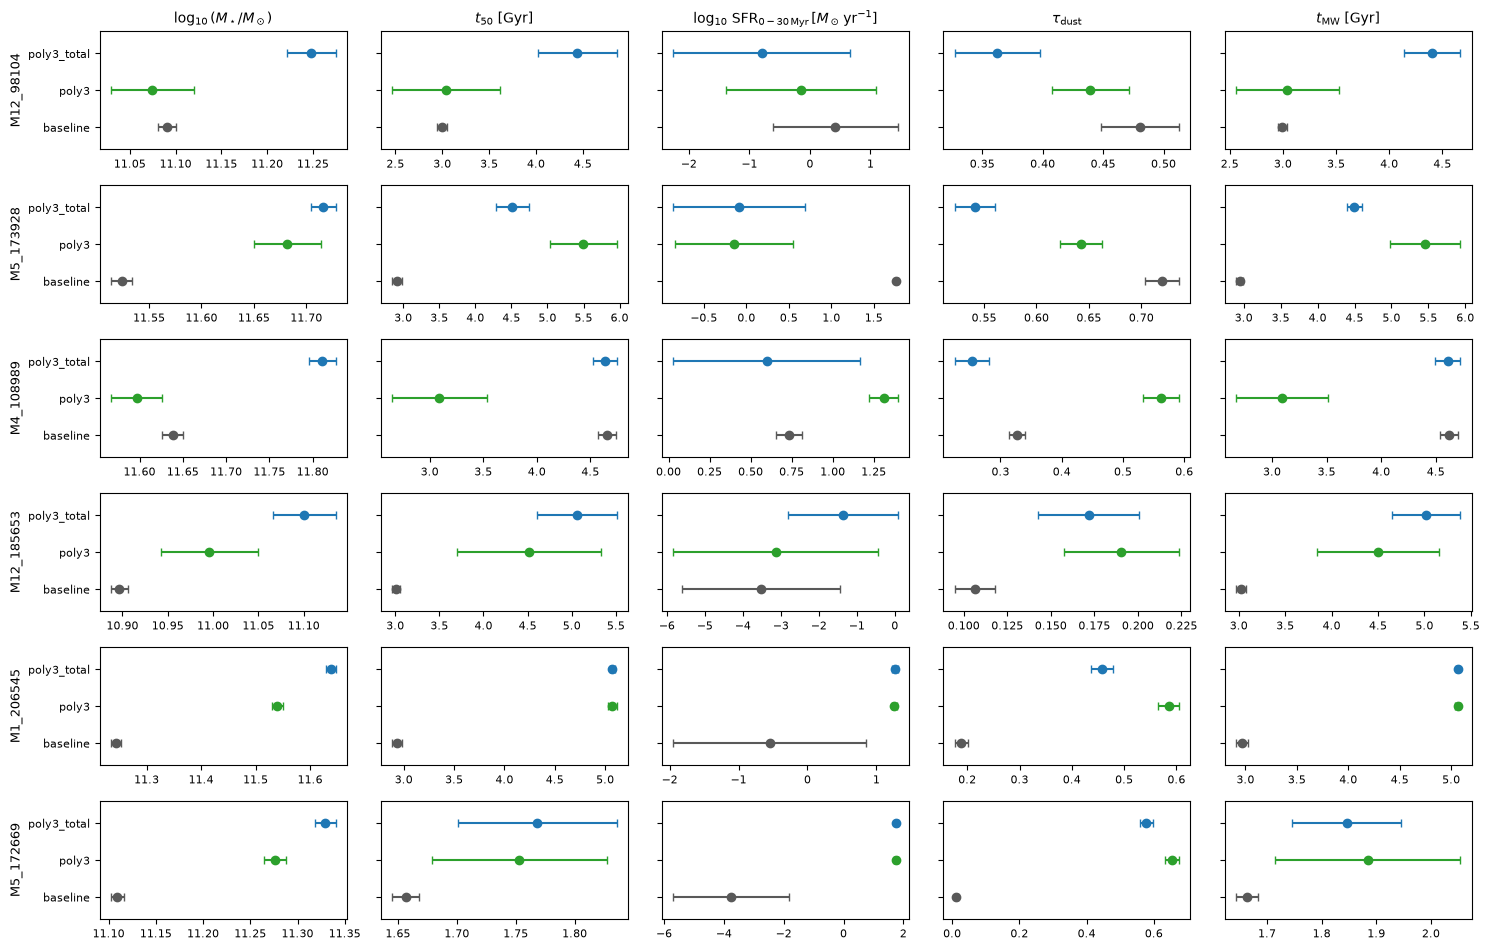

In [7]:
params = ["logmass", "t50", "log_sfr", "tau_dust", "age"]
fig, axes = plt.subplots(len(galaxies), len(params), figsize=(3.0 * len(params), 1.6 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for c, name in enumerate(params):
        ax = axes[r, c]
        for i, arm in enumerate(ARMS):
            if (target, arm) not in table.index:
                continue
            row = table.loc[(target, arm)]
            ax.errorbar(row[f"{name}_q50"], i, xerr=row[f"{name}_hw"], fmt="o", color=COLOURS[arm], capsize=3)
        ax.set_yticks(range(len(ARMS)))
        ax.set_yticklabels(ARMS if c == 0 else [""] * len(ARMS), fontsize=8)
        ax.set_ylim(-0.6, len(ARMS) - 0.4)
        ax.tick_params(axis="x", labelsize=8)
        if r == 0:
            ax.set_title(LABELS[name], fontsize=10)
        if c == 0:
            ax.set_ylabel(target, fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "parameters-before-after.png", dpi=130)
plt.show()


## Mock: a 4 percent tilt on the spectrum only

- Truth: posterior median of the stored M5_172669 fit.
- Pull = (median − truth) / half width.
- Recovered $s\,P(\lambda)$ against the injected tilt.


,logmass,Z,afe,tau_dust,age,logmass_hw,Z_hw,afe_hw,tau_dust_hw,age_hw
arm,,,,,,,,,,
mock_tilt4_baseline,5.38,-0.46,-0.19,32.23,1.01,0.01,0.01,0.01,0.00,0.11
mock_tilt4_poly3,1.38,-0.68,-0.03,0.71,0.64,0.01,0.01,0.01,0.02,0.10


mock_tilt4_poly3: max |recovered - injected| over fitted pixels = 0.0097


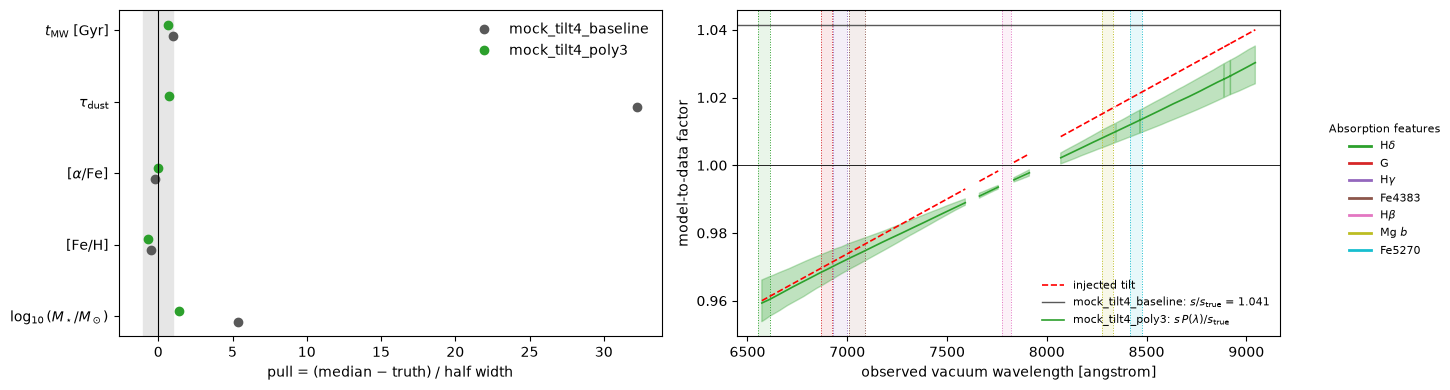

In [8]:
def unit_mass_sfh(logsfr_ratios, lookback_gyr):
    log_sfr = np.concatenate([[0.0], -np.cumsum(logsfr_ratios)])
    sfr = 10.0 ** log_sfr
    dt = np.diff(lookback_gyr * 1e9)
    w = 0.5 * (np.concatenate([[0.0], dt]) + np.concatenate([dt, [0.0]]))
    return sfr / np.sum(sfr * w)


def mass_weighted_age(history, lookback_gyr):
    dt = np.diff(lookback_gyr) * 1e9
    masses = 0.5 * (history[:-1] + history[1:]) * dt
    ages = 0.5 * (lookback_gyr[:-1] + lookback_gyr[1:])
    return float(np.sum(masses * ages) / np.sum(masses))


mocks = {a: fits[(a, "M5_172669")] for a in MOCK_ARMS if (a, "M5_172669") in fits}
if mocks:
    any_fit = next(iter(mocks.values()))
    truth = any_fit["truth"]
    lookback = any_fit["sfh"]["lookback_time_gyr"]
    truth_values = {"logmass": truth["logmass"][0], "Z": truth["Z"][0] + FEH_OFFSET, "afe": truth["afe"][0],
                    "tau_dust": truth["diffuse_tau_kc"][0],
                    "age": mass_weighted_age(unit_mass_sfh(truth["logsfr_ratios"], lookback), lookback)}
    pull_rows = []
    for arm, fit in mocks.items():
        row = table.loc[("M5_172669", arm)]
        pull_rows.append({"arm": arm, **{k: (row[f"{k}_q50"] - v) / row[f"{k}_hw"] for k, v in truth_values.items()},
                          **{f"{k}_hw": row[f"{k}_hw"] for k in truth_values}})
    pulls = pd.DataFrame(pull_rows).set_index("arm")
    display(pulls.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, (name, value) in enumerate(truth_values.items()):
        for j, arm in enumerate(mocks):
            axes[0].plot(pulls.loc[arm, name], i + 0.15 * (j - 0.5), "o", color=COLOURS[arm],
                         label=arm if i == 0 else None)
    axes[0].axvspan(-1, 1, color="0.9")
    axes[0].axvline(0, color="k", lw=0.8)
    axes[0].set_yticks(range(len(truth_values)))
    axes[0].set_yticklabels([LABELS[k] for k in truth_values])
    axes[0].set_xlabel("pull = (median − truth) / half width")
    axes[0].legend(frameon=False)
    spec = any_fit["spectrum"]
    wave = spec["wavelength"]
    mask = spec["mask"].astype(bool)
    fitted = wave[mask]
    injected = 1.0 + 0.04 * (2.0 * (wave - fitted.min()) / (fitted.max() - fitted.min()) - 1.0)
    axes[1].plot(wave, np.where(mask, injected, np.nan), "r--", lw=1.2, label="injected tilt")
    for arm, fit in mocks.items():
        if fit["calibration"] is None:
            scaling = fit["summary"].loc["spectrum_scaling", "q50"] / truth["spectrum_scaling"][0]
            axes[1].axhline(scaling, color=COLOURS[arm], lw=1.0,
                            label=f"{arm}: $s / s_{{\\rm true}}$ = {scaling:.3f}")
            continue
        cal = fit["calibration"]
        scaling = fit["summary"].loc["spectrum_scaling", "q50"] / truth["spectrum_scaling"][0]
        axes[1].fill_between(wave, np.where(mask, scaling * cal["polynomial_q16"], np.nan),
                             np.where(mask, scaling * cal["polynomial_q84"], np.nan), color=COLOURS[arm], alpha=0.3)
        axes[1].plot(wave, np.where(mask, scaling * cal["polynomial_q50"], np.nan), color=COLOURS[arm], lw=1.2,
                     label=f"{arm}: $s\\,P(\\lambda) / s_{{\\rm true}}$")
        recovered = scaling * cal["polynomial_q50"]
        print(f"{arm}: max |recovered - injected| over fitted pixels = "
              f"{np.max(np.abs(recovered - injected)[mask]):.4f}")
    axes[1].axhline(1.0, color="k", lw=0.6)
    axes[1].set_ylabel("model-to-data factor")
    mark_absorption_features(axes[1], any_fit["attrs"]["redshift"],
                             xlabel="observed vacuum wavelength [angstrom]")
    axes[1].legend(frameon=False, fontsize=8)
    spectral_tight_layout(fig)
    fig.savefig(RESULTS / "mock-tilt.png", dpi=130)
    plt.show()


## What the polynomial absorbs, and what it must not

- Top: photometry fixes the absolute scale and the broadband shape.
- Middle: data / uncalibrated model, the fitted $P(\lambda)$, and the three basis shapes.
- Bottom: dust tilt (degenerate with $P$ on the spectrum alone) and a line (too narrow for $P$).


explainer uses poly3_total/M5_172669
dust tilt across the fitted window for delta tau = 0.2: +14.6 percent
spectral window: 6572-9045 angstrom observed, 4098-5640 rest; 3602 fitted pixels; shortest bend of order 3: 824 angstrom


/var/folders/x8/n5px4tbj1vb_8nwzfzd674hm0000gp/T/ipykernel_1907/2587022005.py:53: RuntimeWarning: All-NaN slice encountered
  binned = [np.nanmedian(ratio[(wave >= lo) & (wave < hi)]) for lo, hi in zip(edges[:-1], edges[1:])]


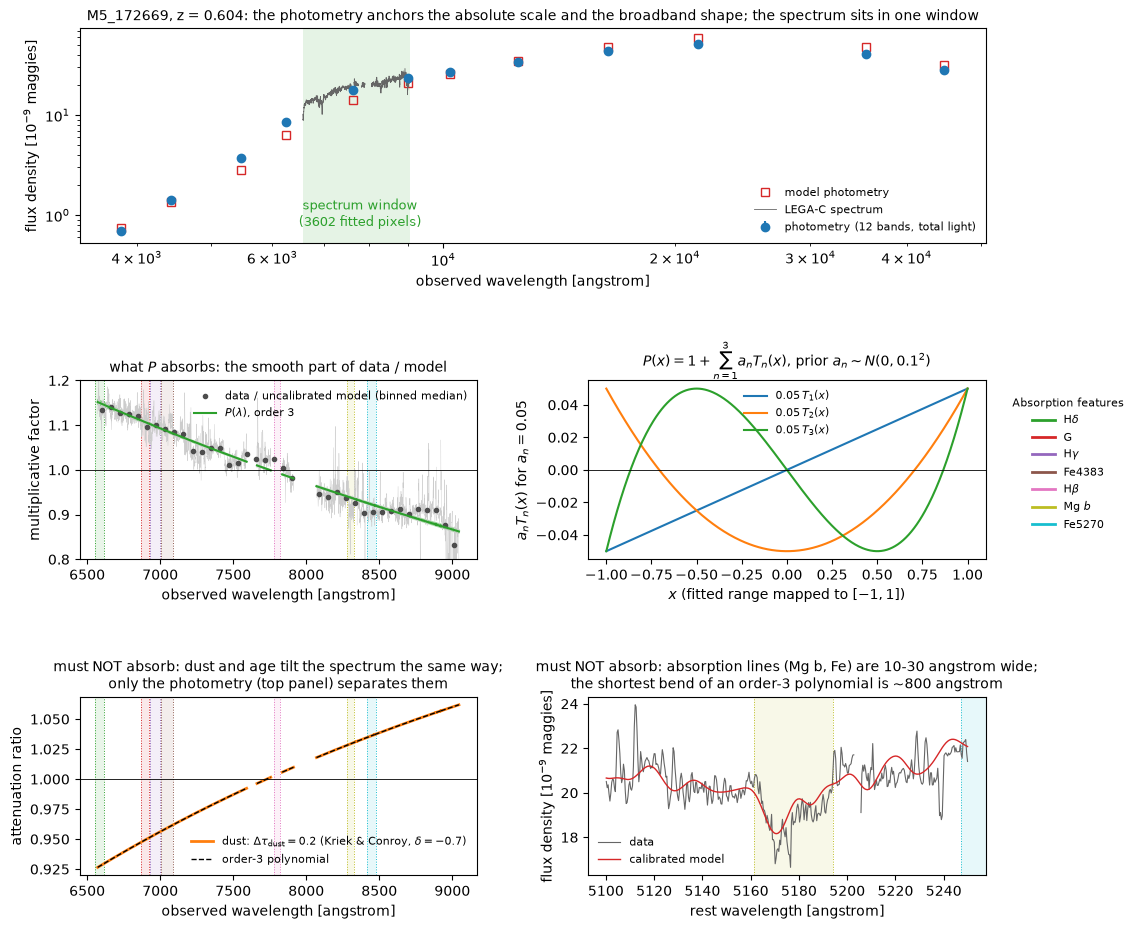

In [9]:
def calzetti_k(wave_aa):
    x = 1e4 / wave_aa                                   # inverse micron
    k = np.where(wave_aa >= 6300.0, 2.659 * (-1.857 + 1.040 * x) + 4.05,
                 2.659 * (-2.156 + 1.509 * x - 0.198 * x**2 + 0.011 * x**3) + 4.05)
    return k


def kriek_conroy_transmission(rest_wave_aa, tau_v, delta=-0.7):
    tau = tau_v * calzetti_k(rest_wave_aa) / 4.05 * (rest_wave_aa / 5500.0) ** delta
    return np.exp(-tau)


candidates = [("poly3_total", "M5_172669"), ("poly3", "M5_172669")]
candidates += [(a, t) for a, t in fits if a in ("poly3_total", "poly3")]
arm, example = next(key for key in candidates if key in fits)
fit = fits[(arm, example)]
print(f"explainer uses {arm}/{example}")
z = fit["attrs"]["redshift"]
spec, phot, cal = fit["spectrum"], fit["photometry"], fit["calibration"]
wave, mask = spec["wavelength"], spec["mask"].astype(bool)
CGS_FNU_PER_MAGGIE = 3631e-23                              # the spectrum is stored in F_nu [cgs]
observed = np.where(mask, spec["observed"], np.nan)
observed_maggies = observed / CGS_FNU_PER_MAGGIE
model_maggies = spec["posterior_q50"] / CGS_FNU_PER_MAGGIE
model_uncal = spec["posterior_q50"] / cal["polynomial_q50"]

fig = plt.figure(figsize=(12, 11))
grid = fig.add_gridspec(3, 2, height_ratios=[1.2, 1.0, 1.0], hspace=0.72, wspace=0.28, right=0.88)
ax_sed = fig.add_subplot(grid[0, :])
ax_ratio = fig.add_subplot(grid[1, 0])
ax_basis = fig.add_subplot(grid[1, 1])
ax_dust = fig.add_subplot(grid[2, 0])
ax_line = fig.add_subplot(grid[2, 1])

# top: the anchor
scale = 1e9
ax_sed.errorbar(phot["wavelength"], scale * phot["observed"], yerr=scale * phot["uncertainty"], fmt="o",
                color="tab:blue", label="photometry (12 bands, total light)")
ax_sed.plot(phot["wavelength"], scale * phot["posterior_q50"], "s", mfc="none", color="tab:red", label="model photometry")
ax_sed.plot(wave, scale * observed_maggies, color="0.4", lw=0.6, label="LEGA-C spectrum")
ax_sed.axvspan(wave[mask].min(), wave[mask].max(), color="tab:green", alpha=0.12, lw=0)
ax_sed.set(xscale="log", yscale="log", xlabel="observed wavelength [angstrom]", ylabel=r"flux density [$10^{-9}$ maggies]")
ax_sed.set_title(f"{example}, z = {z:.3f}: the photometry anchors the absolute scale and the broadband shape; "
                 "the spectrum sits in one window", fontsize=10)
ax_sed.text(wave[mask].mean(), 0.06, f"spectrum window\n({int(mask.sum())} fitted pixels)", ha="center", va="bottom",
            transform=ax_sed.get_xaxis_transform(), fontsize=9, color="tab:green")
ax_sed.legend(frameon=False, fontsize=8, loc="lower right")

# middle left: what P absorbs
ratio = np.where(mask, spec["observed"] / model_uncal, np.nan)
edges = np.linspace(wave[mask].min(), wave[mask].max(), 41)
centres = 0.5 * (edges[1:] + edges[:-1])
binned = [np.nanmedian(ratio[(wave >= lo) & (wave < hi)]) for lo, hi in zip(edges[:-1], edges[1:])]
ax_ratio.plot(wave, ratio, color="0.8", lw=0.3)
ax_ratio.plot(centres, binned, "o", color="0.3", ms=3, label="data / uncalibrated model (binned median)")
ax_ratio.fill_between(wave, np.where(mask, cal["polynomial_q16"], np.nan), np.where(mask, cal["polynomial_q84"], np.nan),
                      color="tab:green", alpha=0.35)
ax_ratio.plot(wave, np.where(mask, cal["polynomial_q50"], np.nan), color="tab:green", lw=1.5, label=r"$P(\lambda)$, order 3")
ax_ratio.axhline(1, color="k", lw=0.6)
ax_ratio.set_ylim(0.8, 1.2)
ax_ratio.set(xlabel="observed wavelength [angstrom]", ylabel="multiplicative factor")
ax_ratio.set_title("what $P$ absorbs: the smooth part of data / model", fontsize=10)
ax_ratio.legend(frameon=False, fontsize=8)

# middle right: the basis
x = np.linspace(-1, 1, 400)
basis = chebvander(x, 3)
for n in range(1, 4):
    ax_basis.plot(x, 0.05 * basis[:, n], label=rf"$0.05\,T_{n}(x)$")
ax_basis.axhline(0, color="k", lw=0.6)
ax_basis.set(xlabel=r"$x$ (fitted range mapped to $[-1, 1]$)", ylabel=r"$a_n T_n(x)$ for $a_n = 0.05$")
ax_basis.set_title(r"$P(x) = 1 + \sum_{n=1}^{3} a_n T_n(x)$, prior $a_n \sim N(0, 0.1^2)$", fontsize=10)
ax_basis.legend(frameon=False, fontsize=8)

# bottom left: degenerate with dust on the spectrum alone
rest = wave / (1 + z)
ratio_dust = kriek_conroy_transmission(rest, 0.30) / kriek_conroy_transmission(rest, 0.10)
ratio_dust = ratio_dust / np.nanmean(ratio_dust[mask])
xw = (wave - 0.5 * (wave[mask].min() + wave[mask].max())) / (0.5 * (wave[mask].max() - wave[mask].min()))
tilt_fit = np.polyfit(xw[mask], ratio_dust[mask], 3)
dust_tilt = ratio_dust[mask][-1] / ratio_dust[mask][0] - 1.0
print(f"dust tilt across the fitted window for delta tau = 0.2: {100 * dust_tilt:+.1f} percent")
print(f"spectral window: {wave[mask].min():.0f}-{wave[mask].max():.0f} angstrom observed, "
      f"{wave[mask].min() / (1 + z):.0f}-{wave[mask].max() / (1 + z):.0f} rest; {int(mask.sum())} fitted pixels; "
      f"shortest bend of order 3: {(wave[mask].max() - wave[mask].min()) / 3:.0f} angstrom")
ax_dust.plot(wave, np.where(mask, ratio_dust, np.nan), color="tab:orange", lw=2,
             label=r"dust: $\Delta\tau_{\rm dust} = 0.2$ (Kriek & Conroy, $\delta = -0.7$)")
ax_dust.plot(wave, np.where(mask, np.polyval(tilt_fit, xw), np.nan), "k--", lw=1, label="order-3 polynomial")
ax_dust.axhline(1, color="k", lw=0.6)
ax_dust.set(xlabel="observed wavelength [angstrom]", ylabel="attenuation ratio")
ax_dust.set_title("must NOT absorb: dust and age tilt the spectrum the same way;\nonly the photometry (top panel) separates them", fontsize=10)
ax_dust.legend(frameon=False, fontsize=8)

# bottom right: too narrow for P
window = (rest > 5100) & (rest < 5250)
ax_line.plot(rest[window], observed_maggies[window] * scale, color="0.4", lw=0.8, label="data")
ax_line.plot(rest[window], model_maggies[window] * scale, color="tab:red", lw=1.0, label="calibrated model")
ax_line.set(xlabel="rest wavelength [angstrom]", ylabel=r"flux density [$10^{-9}$ maggies]")
ax_line.set_title("must NOT absorb: absorption lines (Mg b, Fe) are 10-30 angstrom wide;\n"
                  "the shortest bend of an order-3 polynomial is ~800 angstrom", fontsize=10)
ax_line.legend(frameon=False, fontsize=8)
# The SED and basis panels carry no wavelength axis in angstrom, so they stay bare.
mark_absorption_features(ax_ratio, z, xlabel="observed wavelength [angstrom]")
mark_absorption_features(ax_dust, z, xlabel="observed wavelength [angstrom]")
mark_absorption_features(ax_line, 0.0, xlabel="rest wavelength [angstrom]")
fig.savefig(RESULTS / "calibration-explainer.png", dpi=130, bbox_inches="tight")
plt.show()


## Wiki figures

- Copy the figures beside the wiki note.


In [10]:
WIKI_FIGURES.mkdir(parents=True, exist_ok=True)
for png in sorted(RESULTS.glob("*.png")):
    shutil.copy2(png, WIKI_FIGURES / png.name)
print(sorted(p.name for p in WIKI_FIGURES.glob("*.png")))


['calibration-explainer.png', 'chi2-M12_185653.png', 'chi2-M12_98104.png', 'chi2-M1_206545.png', 'chi2-M4_108989.png', 'chi2-M5_172669.png', 'chi2-M5_173928.png', 'mock-tilt.png', 'parameters-before-after.png', 'polynomial-vectors.png']
